# Cluster + majority-vote dialect ID -- fully automatic variant

A seventh method, the automatic counterpart to
`06_cluster_propagation.ipynb`: **same** sentence-embedding K-Means
clustering (k=100/group, `k-means++` init, tokenize -> average token
embeddings via the frozen `CBOWAttention`), but **no human annotation
step at all**. Each cluster's label is decided by a **majority vote over
its own training members' existing (Qwen-generated) `train.jsonl`
labels** -- unlike notebook 06, which deliberately never let clustering
or labeling see those labels (only a diagnostic peek). Here, the whole
point is the opposite: use the full training-label signal, just applied
*per cluster* instead of *per row*, to see how much a K-Means clustering
step adds (or costs) versus classifying every row directly.

**Pipeline**: cluster `train.jsonl` (script-gated, `code_switch`/`other`
excluded, same convention as everywhere else) -> label each cluster by
its members' majority `label` -> assign each `test.jsonl` row to its
nearest **train-fitted** centroid (no leakage) -> predict that cluster's
majority label -> compare to the real test label.

Fully automatic end to end -- no webpage, no waiting, runs in one pass.
Run this notebook's kernel from the GPU venv (`ai-gpu`).


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"
WORD2VEC_ATTENTION_DIR = ROOT / "Embeddings" / "word2vec_attention"

sys.path.insert(0, str(WORD2VEC_ATTENTION_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Tokenization"))
from model import CBOWAttention  # noqa: E402
from tokenizer_utils import load_tokenizer  # noqa: E402

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")  # embedding lookups only -- GPU not needed


## 1. Script-gating (same convention as every other method here)

In [2]:
import re

_MENTION_WITH_FRAGMENT_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = re.compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")
_ARABIC_RE = re.compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
_LATIN_RE = re.compile(r"[a-zA-Z\u00c0-\u024f]")

ARABIC_CLASSES = ["msa", "darija"]
LATIN_CLASSES = ["arabize", "french", "english"]
GROUP_CLASSES = {"arabic": ARABIC_CLASSES, "latin": LATIN_CLASSES}

MAX_CHARS = 500  # same truncation convention as label_dataset.py's MAX_PROMPT_CHARS


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def script_of(text: str) -> str:
    has_ar = bool(_ARABIC_RE.search(text))
    has_lat = bool(_LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


def load_group_rows(split: str, group: str) -> list[dict]:
    rows = []
    with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            cleaned = clean_for_classification(r["text"])
            if script_of(cleaned) != group:
                continue
            rows.append({"id": r["id"], "text": r["text"], "label": r["label"]})
    return rows


## 2. Load the frozen embedder + sentence embeddings

Identical to notebook 06: tokenize the whole text, average its token
embeddings -- no per-word pooling, no attention/context block.

In [3]:
meta = json.loads((WORD2VEC_ATTENTION_DIR / "data" / "meta.json").read_text(encoding="utf-8"))
tok = load_tokenizer(meta["tokenizer"]["key"], meta["tokenizer"]["vocab_size"])
vocab_size = meta["tokenizer"]["vocab_size_actual"]
PAD_ID = 0

checkpoints = sorted(
    (WORD2VEC_ATTENTION_DIR / "models").glob("checkpoint_step*.pt"),
    key=lambda p: int(p.stem.split("step")[-1]),
)
CHECKPOINT = checkpoints[-1]
ckpt = torch.load(CHECKPOINT, map_location=device)
ckpt_args = ckpt["args"]

embedder = CBOWAttention(
    vocab_size=vocab_size, embed_dim=ckpt_args["embed_dim"],
    num_heads=ckpt_args["num_heads"], ff_dim=ckpt_args["ff_dim"],
).to(device)
embedder.load_state_dict(ckpt["model_state_dict"])
embedder.eval()

EMBED_DIM = ckpt_args["embed_dim"]
embedding_matrix = embedder.input_embeddings.weight.detach().cpu().numpy()
print(f"Loaded checkpoint step={ckpt['step']:,} ({CHECKPOINT.name}), embed_dim={EMBED_DIM}")


def sentence_embedding(text: str) -> np.ndarray:
    ids = [i for i in tok.encode(text[:MAX_CHARS]) if i != PAD_ID and i < vocab_size]
    if not ids:
        return np.zeros(EMBED_DIM, dtype=np.float32)
    return embedding_matrix[ids].mean(axis=0)


Loaded checkpoint step=675,000 (checkpoint_step675000.pt), embed_dim=128


## 3. Cluster `train.jsonl` (k=100/group, k-means++) and label each cluster by majority vote

The only real difference from notebook 06: instead of picking one
nearest-to-centroid point per cluster for a human to label, every
cluster's label is decided immediately, automatically, from a majority
vote over **all** its training members' existing labels.

In [4]:
K = 100

group_data = {}
for group in ("arabic", "latin"):
    rows = load_group_rows("train", group)
    embeddings = np.stack([sentence_embedding(r["text"]) for r in rows])

    kmeans = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=SEED)
    cluster_ids = kmeans.fit_predict(embeddings)

    cluster_labels = {}
    cluster_purities = {}
    for c in range(K):
        member_idx = np.where(cluster_ids == c)[0]
        if len(member_idx) == 0:
            continue
        member_labels = [rows[i]["label"] for i in member_idx]
        counts = {}
        for l in member_labels:
            counts[l] = counts.get(l, 0) + 1
        majority_label, majority_count = max(counts.items(), key=lambda kv: kv[1])
        cluster_labels[c] = majority_label
        cluster_purities[c] = majority_count / len(member_labels)

    weighted_purity = np.average(
        list(cluster_purities.values()),
        weights=[(cluster_ids == c).sum() for c in cluster_purities],
    )
    group_data[group] = dict(rows=rows, embeddings=embeddings, kmeans=kmeans,
                              cluster_ids=cluster_ids, cluster_labels=cluster_labels)
    print(f"{group}: {len(rows):,} train rows, {len(cluster_labels)} non-empty clusters, "
          f"weighted majority-vote purity={weighted_purity:.3f} "
          f"(chance={1 / len(GROUP_CLASSES[group]):.3f})")


arabic: 6,660 train rows, 100 non-empty clusters, weighted majority-vote purity=0.795 (chance=0.500)


latin: 4,563 train rows, 100 non-empty clusters, weighted majority-vote purity=0.831 (chance=0.333)


## 4. Evaluate on `test.jsonl`

Same procedure as notebook 06's Phase 2: embed each test row the same
way, assign it to its **nearest train-fitted centroid**
(`kmeans.predict`), predict that cluster's majority-vote label, compare
to the real label. No leakage -- test rows never influence clustering or
cluster labeling.

In [5]:
all_results = {}
for group, gd in group_data.items():
    classes = GROUP_CLASSES[group]
    test_rows = load_group_rows("test", group)
    test_embeddings = np.stack([sentence_embedding(r["text"]) for r in test_rows])
    pred_cluster_ids = gd["kmeans"].predict(test_embeddings)

    y_true = [r["label"] for r in test_rows]
    y_pred = [gd["cluster_labels"][c] for c in pred_cluster_ids]

    acc = accuracy_score(y_true, y_pred)
    all_results[group] = dict(y_true=y_true, y_pred=y_pred, accuracy=acc)
    print(f"\n{group}: accuracy={acc:.4f} ({sum(t == p for t, p in zip(y_true, y_pred))}/{len(y_true)})")

    print("Per-class accuracy:")
    for cname in classes:
        idx = [i for i, t in enumerate(y_true) if t == cname]
        n_correct = sum(y_pred[i] == cname for i in idx)
        print(f"  {cname:<10} {n_correct:>4}/{len(idx):<4} acc={n_correct / len(idx) if idx else float('nan'):.3f}")



arabic: accuracy=0.7802 (1299/1665)
Per-class accuracy:
  msa         266/542  acc=0.491
  darija     1033/1123 acc=0.920



latin: accuracy=0.8284 (946/1142)
Per-class accuracy:
  arabize     554/621  acc=0.892
  french      350/415  acc=0.843
  english      42/106  acc=0.396


## 5. Confusion matrices

In [6]:
def print_confusion(classes, y_true, y_pred, title):
    n = len(classes)
    idx = {c: i for i, c in enumerate(classes)}
    mat = [[0] * n for _ in range(n)]
    for t, p in zip(y_true, y_pred):
        mat[idx[t]][idx[p]] += 1
    print(f"\n{title} confusion matrix (rows=true, cols=predicted):")
    print("true\\pred" + "".join(f"{c:>12}" for c in classes))
    for i, c in enumerate(classes):
        print(f"{c:<10}" + "".join(f"{mat[i][j]:>12}" for j in range(n)))


for group, res in all_results.items():
    print_confusion(GROUP_CLASSES[group], res["y_true"], res["y_pred"], group)



arabic confusion matrix (rows=true, cols=predicted):
true\pred         msa      darija
msa                266         276
darija              90        1033

latin confusion matrix (rows=true, cols=predicted):
true\pred     arabize      french     english
arabize            554          56          11
french              54         350          11
english             37          27          42


## 6. Compared against every other method tried on this task

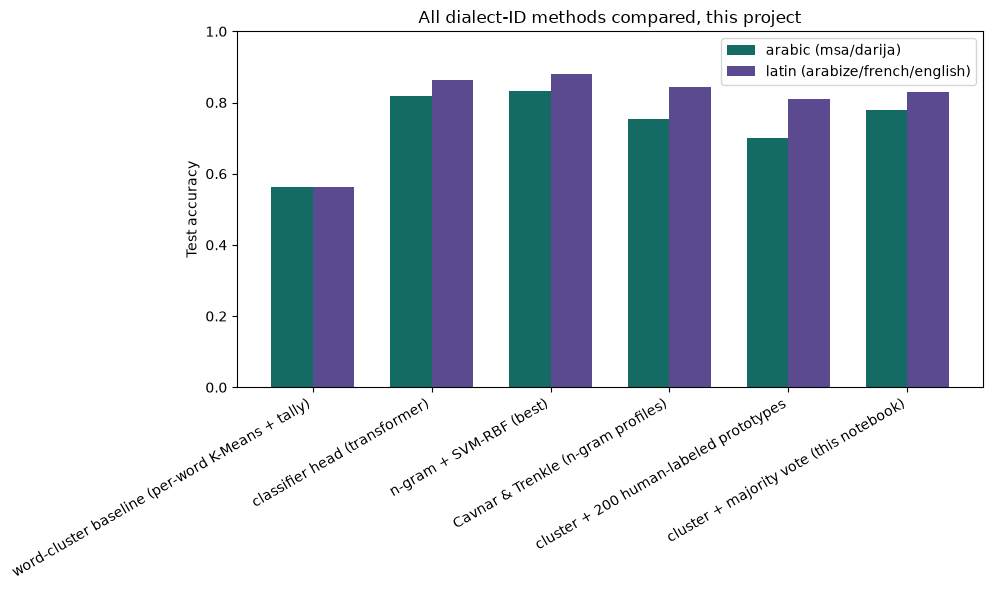

In [7]:
comparison = {
    "word-cluster baseline (per-word K-Means + tally)": {"arabic": 0.562, "latin": 0.562},  # cluster-scored, combined
    "classifier head (transformer)": {"arabic": 0.819, "latin": 0.863},
    "n-gram + SVM-RBF (best)": {"arabic": 0.833, "latin": 0.881},
    "Cavnar & Trenkle (n-gram profiles)": {"arabic": 0.754, "latin": 0.844},
    "cluster + 200 human-labeled prototypes": {"arabic": 0.701, "latin": 0.810},
    "cluster + majority vote (this notebook)": {"arabic": all_results["arabic"]["accuracy"],
                                                  "latin": all_results["latin"]["accuracy"]},
}

fig, ax = plt.subplots(figsize=(10, 6))
methods = list(comparison.keys())
x = np.arange(len(methods))
width = 0.35
ax.bar(x - width / 2, [comparison[m]["arabic"] for m in methods], width, label="arabic (msa/darija)", color="#146b64")
ax.bar(x + width / 2, [comparison[m]["latin"] for m in methods], width, label="latin (arabize/french/english)", color="#5b4a8f")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel("Test accuracy")
ax.set_ylim(0, 1)
ax.set_title("All dialect-ID methods compared, this project")
ax.legend()
plt.tight_layout()
plt.show()
